---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/PDI_python/blob/main/topico3/Topico3.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

---

In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Quando dentro do Colab, clonar o repositório completo para garantir acesso à pasta de imagens
!git clone https://github.com/ppestana-supervisor/PDI_python.git
%cd PDI_python/topico5

# 03 · Visualização de Batches Pré-processados
Neste notebook, vamos explorar como as transformações aplicadas em batches de imagens — como redimensionamento, normalização e **aumentações** — afetam os dados de entrada de um modelo. Isto é fundamental para compreender como estas técnicas ajudam na generalização e robustez do treino.

## 1. Importação das bibliotecas

sta célula reúne todas as bibliotecas necessárias para o carregamento, pré-processamento e visualização de dados de imagem, bem como para a criação dos *DataLoaders* que irão alimentar os modelos de aprendizagem automática.

1. **Bibliotecas principais do PyTorch e TorchVision:**  
   - `torch` fornece as estruturas fundamentais de tensores e operações de treino de redes neurais.  
   - `torchvision` e `torchvision.transforms` disponibilizam conjuntos de dados, transformações e modelos visuais pré-treinados.  
   - `Flowers102` é o dataset específico utilizado neste notebook, com 102 classes de flores.  

2. **Carregamento e gestão de dados:**  
   - `torch.utils.data.DataLoader` permite iterar sobre os dados em *batches*, otimizando o treino e a avaliação dos modelos.  
   - As transformações definidas em `transforms` tratam da conversão e normalização das imagens.

3. **Visualização e suporte:**  
   - `matplotlib.pyplot` e `numpy` são usados para representar graficamente os resultados e manipular matrizes numéricas.  
   - `os` facilita o acesso a diretórios e ficheiros no sistema, útil para organizar datasets e guardar resultados.


In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import Flowers102
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

## 2. Definição de transformações

Esta célula define duas sequências distintas de transformações que serão aplicadas às imagens antes de entrarem no modelo.  
As transformações são combinadas com `transforms.Compose(...)`, permitindo encadear várias operações de forma organizada.

1. **Transformação básica (`transform_basic`):**  
   Inclui apenas os passos essenciais de preparação dos dados:
   - `Resize((128, 128))`: redimensiona todas as imagens para 128×128 píxeis, garantindo dimensão uniforme.  
   - `ToTensor()`: converte a imagem (PIL ou NumPy) num tensor PyTorch, com valores normalizados entre 0 e 1.  
   - `Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])`: centraliza os valores no intervalo `[-1, 1]`, o que melhora a estabilidade numérica e o desempenho dos modelos.

2. **Transformação com *data augmentation* (`transform_augmented`):**  
   Adiciona variações artificiais às imagens originais, simulando diferentes condições de captura:
   - `RandomHorizontalFlip()`: inverte horizontalmente as imagens com probabilidade de 50%.  
   - `RandomRotation(20)`: aplica rotações aleatórias até ±20°.  
   - `ColorJitter(...)`: altera ligeiramente brilho, contraste, saturação e tonalidade, introduzindo diversidade cromática.  
   - Seguem-se as mesmas operações de conversão e normalização da transformação básica.

**Nota pedagógica:**  
A *data augmentation* é uma técnica essencial para melhorar a **capacidade de generalização** dos modelos, sobretudo quando o dataset é pequeno.  
Ao apresentar ao modelo múltiplas versões ligeiramente diferentes da mesma imagem, reduz-se o risco de *overfitting* e aumenta-se a robustez às variações naturais do mundo real (iluminação, ângulo, cor, etc.).  

In [2]:
transform_basic = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

transform_augmented = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

## 3. Carregamento do dataset

Esta célula cria duas versões distintas do conjunto de treino **Flowers102**, aplicando a cada uma as transformações definidas anteriormente: uma versão básica e outra com *data augmentation*.

1. **Definição dos datasets:**  
   - `dataset_basic` carrega o conjunto de treino com a transformação simples (`transform_basic`), que apenas redimensiona, converte e normaliza as imagens.  
   - `dataset_aug` aplica as mesmas operações básicas, mas inclui transformações aleatórias (rotações, inversões, ajustes de cor) definidas em `transform_augmented`.  
   - Ambos os datasets utilizam o parâmetro `download=True`, garantindo que o *Flowers102* é transferido automaticamente se ainda não existir localmente.

2. **Criação dos *DataLoaders*:**  
   - `DataLoader(dataset_basic, batch_size=8, shuffle=True)` cria lotes (*batches*) de 8 imagens por iteração, embaralhando a ordem a cada época.  
   - O mesmo processo é aplicado ao dataset com *augmentation* (`loader_aug`).  
   - Os *DataLoaders* permitem iterar sobre as imagens de forma eficiente, gerando automaticamente lotes prontos para o treino ou visualização.

**Nota pedagógica:**  
Ter duas versões do mesmo dataset é útil para comparar o impacto da *data augmentation*.  
Mesmo quando as imagens de base são idênticas, as transformações aleatórias fazem com que cada lote gerado a partir de `loader_aug` apresente variações visuais ligeiras — refletindo as condições de iluminação, rotação ou posição que o modelo poderá encontrar no mundo real.  

O **tamanho do batch** (`batch_size`) também influencia diretamente o comportamento do treino:
- Batches **pequenos** (por exemplo, 8 ou 16 imagens) introduzem mais variação no gradiente a cada passo, o que pode ajudar o modelo a generalizar melhor, mas tornam o treino menos estável e ligeiramente mais lento.  
- Batches **grandes** (64, 128 ou mais) tornam o treino mais estável e rápido (melhor aproveitamento da GPU), mas podem levar o modelo a convergir para mínimos menos generalizáveis.  
- Em geral, escolhe-se o maior *batch size* possível que caiba na memória da GPU, ajustando a *learning rate* de forma proporcional.

Nos notebooks seguintes, esta decisão terá impacto na rapidez e na suavidade do treino das redes neuronais.

In [3]:
dataset_basic = Flowers102(root='./data', split='train', download=True, transform=transform_basic)
dataset_aug = Flowers102(root='./data', split='train', download=True, transform=transform_augmented)

loader_basic = DataLoader(dataset_basic, batch_size=8, shuffle=True)
loader_aug = DataLoader(dataset_aug, batch_size=8, shuffle=True)

## 4. Função para visualização de batches

Esta célula define uma função de apoio (`imshow_batch`) que serve para visualizar de forma rápida um conjunto de imagens provenientes de um *DataLoader*.  
A função realiza a “desnormalização” das imagens e apresenta-as organizadas numa grelha.

1. **Desnormalização:**  
   - `images = images * 0.5 + 0.5` reverte a normalização aplicada anteriormente, que deslocava os valores de píxel para o intervalo `[-1, 1]`.  
   - Após este passo, as imagens voltam ao intervalo `[0, 1]`, permitindo uma visualização correta das cores.

2. **Criação da grelha de imagens:**  
   - `torchvision.utils.make_grid(images)` agrupa várias imagens num único tensor para exibição.  
   - O resultado é convertido para *NumPy* (`.numpy()`) e transposto (`np.transpose(npimg, (1, 2, 0))`) para o formato esperado pelo Matplotlib — com a dimensão dos canais de cor no final.

3. **Visualização:**  
   - As imagens são mostradas com `plt.imshow(...)`, sem eixos, e com um título configurável (`title`) que indica a origem do lote (por exemplo, “Transformação básica” ou “Com data augmentation”).

**Nota pedagógica:**  
Esta função é uma ferramenta prática para inspecionar visualmente batches de dados.  
Verificar se as imagens estão corretamente dimensionadas, coloridas e bem distribuídas é uma etapa importante antes de iniciar qualquer treino.  
Permite também comparar visualmente o efeito de diferentes transformações ou estratégias de *augmentation*, observando como estas modificam o aspeto das imagens a cada iteração.

In [4]:
def imshow_batch(images, labels, title):
    images = images * 0.5 + 0.5  # unnormalize
    npimg = torchvision.utils.make_grid(images).numpy()
    plt.figure(figsize=(12, 6))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

## 5. Visualização de batches com e sem augmentação

Esta célula apresenta, lado a lado, dois batches de imagens retirados dos *DataLoaders* definidos anteriormente:  
um com transformações básicas e outro com *data augmentation*.  
O objetivo é visualizar o impacto direto das transformações aleatórias nas imagens do conjunto de treino.

1. **Batch sem *augmentation*:**  
   - `loader_basic` fornece um lote de 8 imagens processadas apenas com `Resize`, `ToTensor` e `Normalize`.  
   - As imagens mantêm o seu aspeto original, servindo como referência visual para o dataset “limpo”.

2. **Batch com *augmentation*:**  
   - `loader_aug` gera outro lote de 8 imagens, aplicando rotações, inversões horizontais e variações de cor.  
   - Como as transformações são aleatórias, mesmo que as imagens venham das mesmas classes, o resultado visual será ligeiramente diferente a cada execução.

3. **Visualização:**  
   - A função `imshow_batch(...)` é usada para mostrar ambos os lotes, um após o outro, com títulos descritivos.  
   - As imagens são mostradas sem eixos, em grelhas compactas, permitindo uma comparação direta entre as versões originais e as transformadas.

**Nota pedagógica:**  
A comparação ilustra claramente o papel da *data augmentation*:  
as imagens continuam a representar as mesmas classes, mas com pequenas variações geométricas e cromáticas.  
Durante o treino, estas alterações ajudam o modelo a **aprender características mais robustas e invariantes** — por exemplo, reconhecer uma flor independentemente da sua orientação, iluminação ou saturação.  

Se a *augmentation* for demasiado intensa (rotações exageradas, alterações extremas de cor, cortes excessivos), pode introduzir ruído e dificultar o treino.  
Por isso, a escolha das transformações deve equilibrar diversidade e realismo, simulando condições plausíveis sem distorcer o significado da imagem.

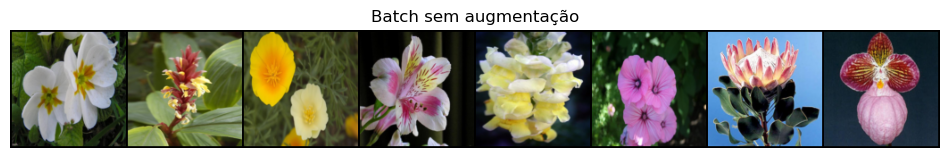

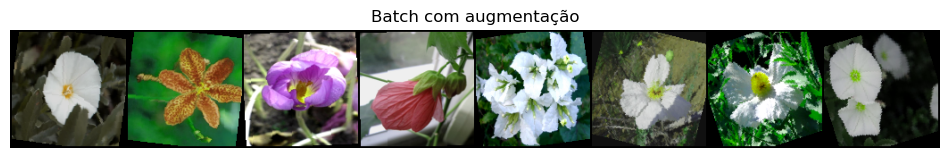

In [5]:
dataiter_basic = iter(loader_basic)
images_basic, labels_basic = next(dataiter_basic)
imshow_batch(images_basic, labels_basic, "Batch sem augmentação")

dataiter_aug = iter(loader_aug)
images_aug, labels_aug = next(dataiter_aug)
imshow_batch(images_aug, labels_aug, "Batch com augmentação")

## 6. Efeito direto das transformações numa única imagem

Esta célula demonstra de forma explícita como as transformações afetam uma imagem individual do conjunto *Flowers102* (no exemplo anterior os batches são aleatórios). 
Pode-se correr várias vezes a célula para ver resultados diferentes.

1. **Transformações definidas:**  
   - `preprocess_transforms`: redimensiona e converte a imagem para tensor, sem alterações adicionais.  
   - `augment_transforms`: inclui operações aleatórias de inversão horizontal, rotação e ajustes de brilho e contraste.

2. **Dataset sem transformações:**  
   O `raw_dataset` é carregado sem argumento `transform=`, o que permite aceder à imagem original em formato PIL, antes de qualquer pré-processamento.

3. **Aplicação manual das transformações:**  
   A mesma imagem é processada duas vezes — uma com as transformações básicas e outra com *augmentation* — para comparação direta.

4. **Visualização lado a lado:**  
   As duas versões são apresentadas em paralelo: “Sem Aumentação” e “Com Aumentação”.  
   Como as transformações incluem elementos aleatórios, o resultado variará a cada execução, evidenciando a diversidade introduzida no treino.

**Nota pedagógica:**  
Esta célula ilustra de forma controlada o efeito da *data augmentation* sobre uma imagem concreta, o que ajuda a compreender visualmente o que o modelo “vê” durante o treino.  
Enquanto nas células anteriores observava-se a diversidade de batches, aqui analisa-se a transformação de uma única amostra, destacando o papel das operações aleatórias na geração de variações realistas.

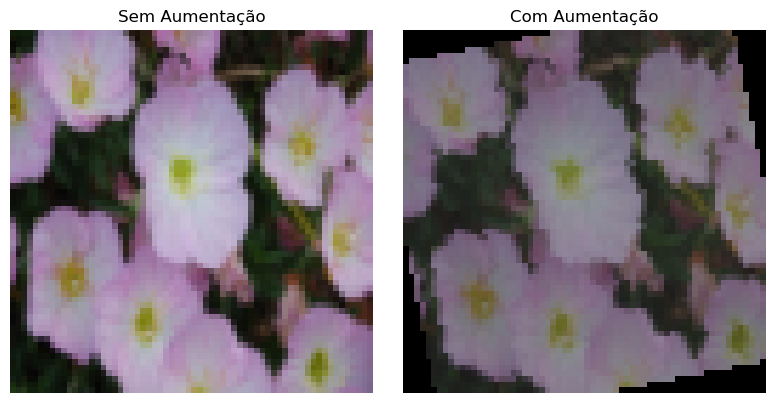

In [6]:
preprocess_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

augment_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.5, contrast=0.5),
    transforms.RandomRotation(30),
    transforms.ToTensor()
])

raw_dataset = Flowers102(root="./data", split="train", download=True)

idx = 0
img_pil = raw_dataset[idx][0]  # (imagem, label)

img_no_aug = preprocess_transforms(img_pil)
img_aug = augment_transforms(img_pil)

def show_tensor_image(tensor, title="", subplot=111):
    img = tensor.clone()
    img = img.permute(1, 2, 0)  # C x H x W -> H x W x C
    img = img.numpy()
    plt.subplot(subplot)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

plt.figure(figsize=(8, 4))
show_tensor_image(img_no_aug, "Sem Aumentação", 121)
show_tensor_image(img_aug, "Com Aumentação", 122)
plt.tight_layout()
plt.show()

## 7. Conclusão

As transformações visuais são uma ferramenta poderosa para melhorar a capacidade do modelo de generalizar. Verificámos como as técnicas de aumentação alteram visualmente os dados, simulando diferentes condições de iluminação, orientação e cor — o que torna o modelo mais robusto a variações no mundo real.